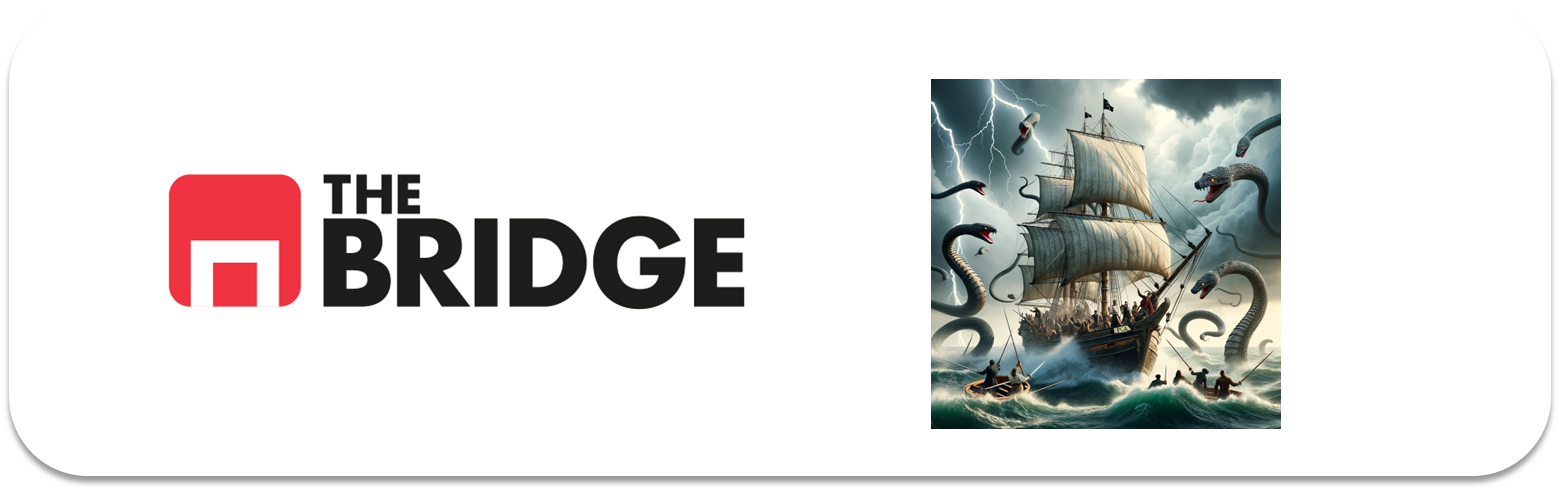

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    SelectFromModel, RFE, SequentialFeatureSelector,
)
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score, classification_report

import bootcampviztools as bt

pd.set_option("display.max_columns", None)
%matplotlib inline

np.random.seed(42)

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


## 1. Carga y preprocesado de datos

In [ ]:
df = pd.read_csv("data/credit_npo.csv")
print(df.shape)
df.head()


(12537, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [ ]:
df.isna().sum()


SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Hay nulos en `MonthlyIncome` (721) y en `NumberOfDependents` (177). Como indica el enunciado, para esta práctica los eliminamos directamente sin imputar nada.

In [ ]:
df = df.dropna()
print("Shape tras quitar nulos:", df.shape)


Shape tras quitar nulos: (11816, 11)


**¿Qué columnas "NumberOf..." convertimos a categóricas?**

Miramos la distribución de cada una de ellas antes de decidir:

In [ ]:
cols_conteo = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate",
               "NumberOfTime60-89DaysPastDueNotWorse", "NumberRealEstateLoansOrLines",
               "NumberOfDependents", "NumberOfOpenCreditLinesAndLoans"]

for c in cols_conteo:
    print(f"--- {c} ---")
    print(df[c].value_counts(normalize=True).sort_index().round(3).head(8))
    print()


--- NumberOfTime30-59DaysPastDueNotWorse ---
NumberOfTime30-59DaysPastDueNotWorse
0    0.831
1    0.115
2    0.034
3    0.011
4    0.005
5    0.002
6    0.002
7    0.000
Name: proportion, dtype: float64

--- NumberOfTimes90DaysLate ---
NumberOfTimes90DaysLate
0    0.944
1    0.033
2    0.012
3    0.005
4    0.003
5    0.001
6    0.001
7    0.000
Name: proportion, dtype: float64

--- NumberOfTime60-89DaysPastDueNotWorse ---
NumberOfTime60-89DaysPastDueNotWorse
0     0.948
1     0.040
2     0.007
3     0.002
4     0.001
5     0.000
11    0.000
98    0.001
Name: proportion, dtype: float64

--- NumberRealEstateLoansOrLines ---
NumberRealEstateLoansOrLines
0    0.358
1    0.351
2    0.219
3    0.045
4    0.015
5    0.006
6    0.002
7    0.001
Name: proportion, dtype: float64

--- NumberOfDependents ---
NumberOfDependents
0.0    0.543
1.0    0.200
2.0    0.153
3.0    0.075
4.0    0.021
5.0    0.005
6.0    0.002
7.0    0.000
Name: proportion, dtype: float64

--- NumberOfOpenCreditLinesAndLoan

Se ve claramente que:

- `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate` y `NumberOfTime60-89DaysPastDueNotWorse` están totalmente dominadas por el valor 0 (83%-95% de los casos) con una cola larguísima de valores raros (incluso un valor "98" que es un típico código de "missing"/error de captura en este dataset). Las convertimos a categóricas de 3 niveles: **"0", "1", "2+"**.
- `NumberRealEstateLoansOrLines` y `NumberOfDependents` están menos concentradas pero también tienen cola larga a partir de un par de unidades. Las convertimos a 3 niveles: **"0", "1-2", "3+"**.
- `NumberOfOpenCreditLinesAndLoans` en cambio tiene una distribución mucho más suave y repartida (no está dominada por un único valor ni tiene apenas huecos), así que la **dejamos numérica** tal cual.

Además de la versión categórica (en texto, útil para los gráficos), creamos también una versión ordinal numérica de cada una (0/1/2), que es la que usaremos en los modelos y en las técnicas de selección de features numéricas.

In [ ]:
df["NumberOfTime30-59DaysPastDueNotWorse_cat"] = np.select(
    [df["NumberOfTime30-59DaysPastDueNotWorse"] == 0, df["NumberOfTime30-59DaysPastDueNotWorse"] == 1],
    ["0", "1"], default="2+")
df["NumberOfTimes90DaysLate_cat"] = np.select(
    [df["NumberOfTimes90DaysLate"] == 0, df["NumberOfTimes90DaysLate"] == 1],
    ["0", "1"], default="2+")
df["NumberOfTime60-89DaysPastDueNotWorse_cat"] = np.select(
    [df["NumberOfTime60-89DaysPastDueNotWorse"] == 0, df["NumberOfTime60-89DaysPastDueNotWorse"] == 1],
    ["0", "1"], default="2+")
df["NumberRealEstateLoansOrLines_cat"] = np.select(
    [df["NumberRealEstateLoansOrLines"] == 0, df["NumberRealEstateLoansOrLines"] <= 2],
    ["0", "1-2"], default="3+")
df["NumberOfDependents_cat"] = np.select(
    [df["NumberOfDependents"] == 0, df["NumberOfDependents"] <= 2],
    ["0", "1-2"], default="3+")

# version ordinal (numerica) de cada categorica, para meterla en modelos y selectores
ord_maps = {
    "NumberOfTime30-59DaysPastDueNotWorse_cat": {"0": 0, "1": 1, "2+": 2},
    "NumberOfTimes90DaysLate_cat": {"0": 0, "1": 1, "2+": 2},
    "NumberOfTime60-89DaysPastDueNotWorse_cat": {"0": 0, "1": 1, "2+": 2},
    "NumberRealEstateLoansOrLines_cat": {"0": 0, "1-2": 1, "3+": 2},
    "NumberOfDependents_cat": {"0": 0, "1-2": 1, "3+": 2},
}
for col, mapping in ord_maps.items():
    df[col + "_ord"] = df[col].map(mapping)

df.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,NumberOfTime30-59DaysPastDueNotWorse_cat,NumberOfTimes90DaysLate_cat,NumberOfTime60-89DaysPastDueNotWorse_cat,NumberRealEstateLoansOrLines_cat,NumberOfDependents_cat,NumberOfTime30-59DaysPastDueNotWorse_cat_ord,NumberOfTimes90DaysLate_cat_ord,NumberOfTime60-89DaysPastDueNotWorse_cat_ord,NumberRealEstateLoansOrLines_cat_ord,NumberOfDependents_cat_ord
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0,0,1,0,0,0,0,1,0,0,0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0,0,0,0,1-2,0,0,0,0,1,0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0,0,0,0,0,1-2,0,0,0,0,1
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0,0,0,0,1-2,3+,0,0,0,1,2
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0,0,0,0,0,1-2,0,0,0,0,1


### Train/test split

Aunque en el notebook de ejemplo de clase se usa todo el dataset como "train" por simplicidad, en esta práctica el propio enunciado nos pide evaluar el modelo final contra test (pasos 3 y 4), así que separamos train/test **antes** de hacer ninguna selección de features. De lo contrario estaríamos usando información del test para decidir qué features son buenas (data leakage) y el resultado final sería demasiado optimista.

Usamos `stratify=y` porque el target está muy desbalanceado (lo vemos justo debajo).

In [ ]:
target = "SeriousDlqin2yrs"

features_num = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio",
                 "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans"]
features_cat = ["NumberOfTime30-59DaysPastDueNotWorse_cat", "NumberOfTimes90DaysLate_cat",
                 "NumberOfTime60-89DaysPastDueNotWorse_cat", "NumberRealEstateLoansOrLines_cat",
                 "NumberOfDependents_cat"]
features_cat_ord = [c + "_ord" for c in features_cat]
features_all = features_num + features_cat_ord

print(df[target].value_counts(normalize=True))

X = df[features_all].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# dataframe de train con todas las columnas (incluye versiones categoricas en texto y el target),
# lo usamos solo para el EDA visual
df_train_full = df.loc[X_train.index].copy()


SeriousDlqin2yrs
0    0.929756
1    0.070244
Name: proportion, dtype: float64
Train: (9452, 10)  Test: (2364, 10)


El target está muy desbalanceado: solo ~7% de los clientes tuvo un impago serio (`SeriousDlqin2yrs = 1`). Esto va a condicionar toda la práctica: usaremos `class_weight="balanced"` en los modelos lineales y la métrica `balanced_accuracy` en vez de accuracy normal, porque con este desbalance un modelo que prediga siempre "0" tendría ~93% de accuracy sin ser nada útil.

## 2. MiniEDA y selección de features

### 2.1 Análisis visual + correlación + covarianza

Primero miramos las distribuciones de las categóricas (incluyendo el target) y cómo se relaciona la media de cada numérica con el target.

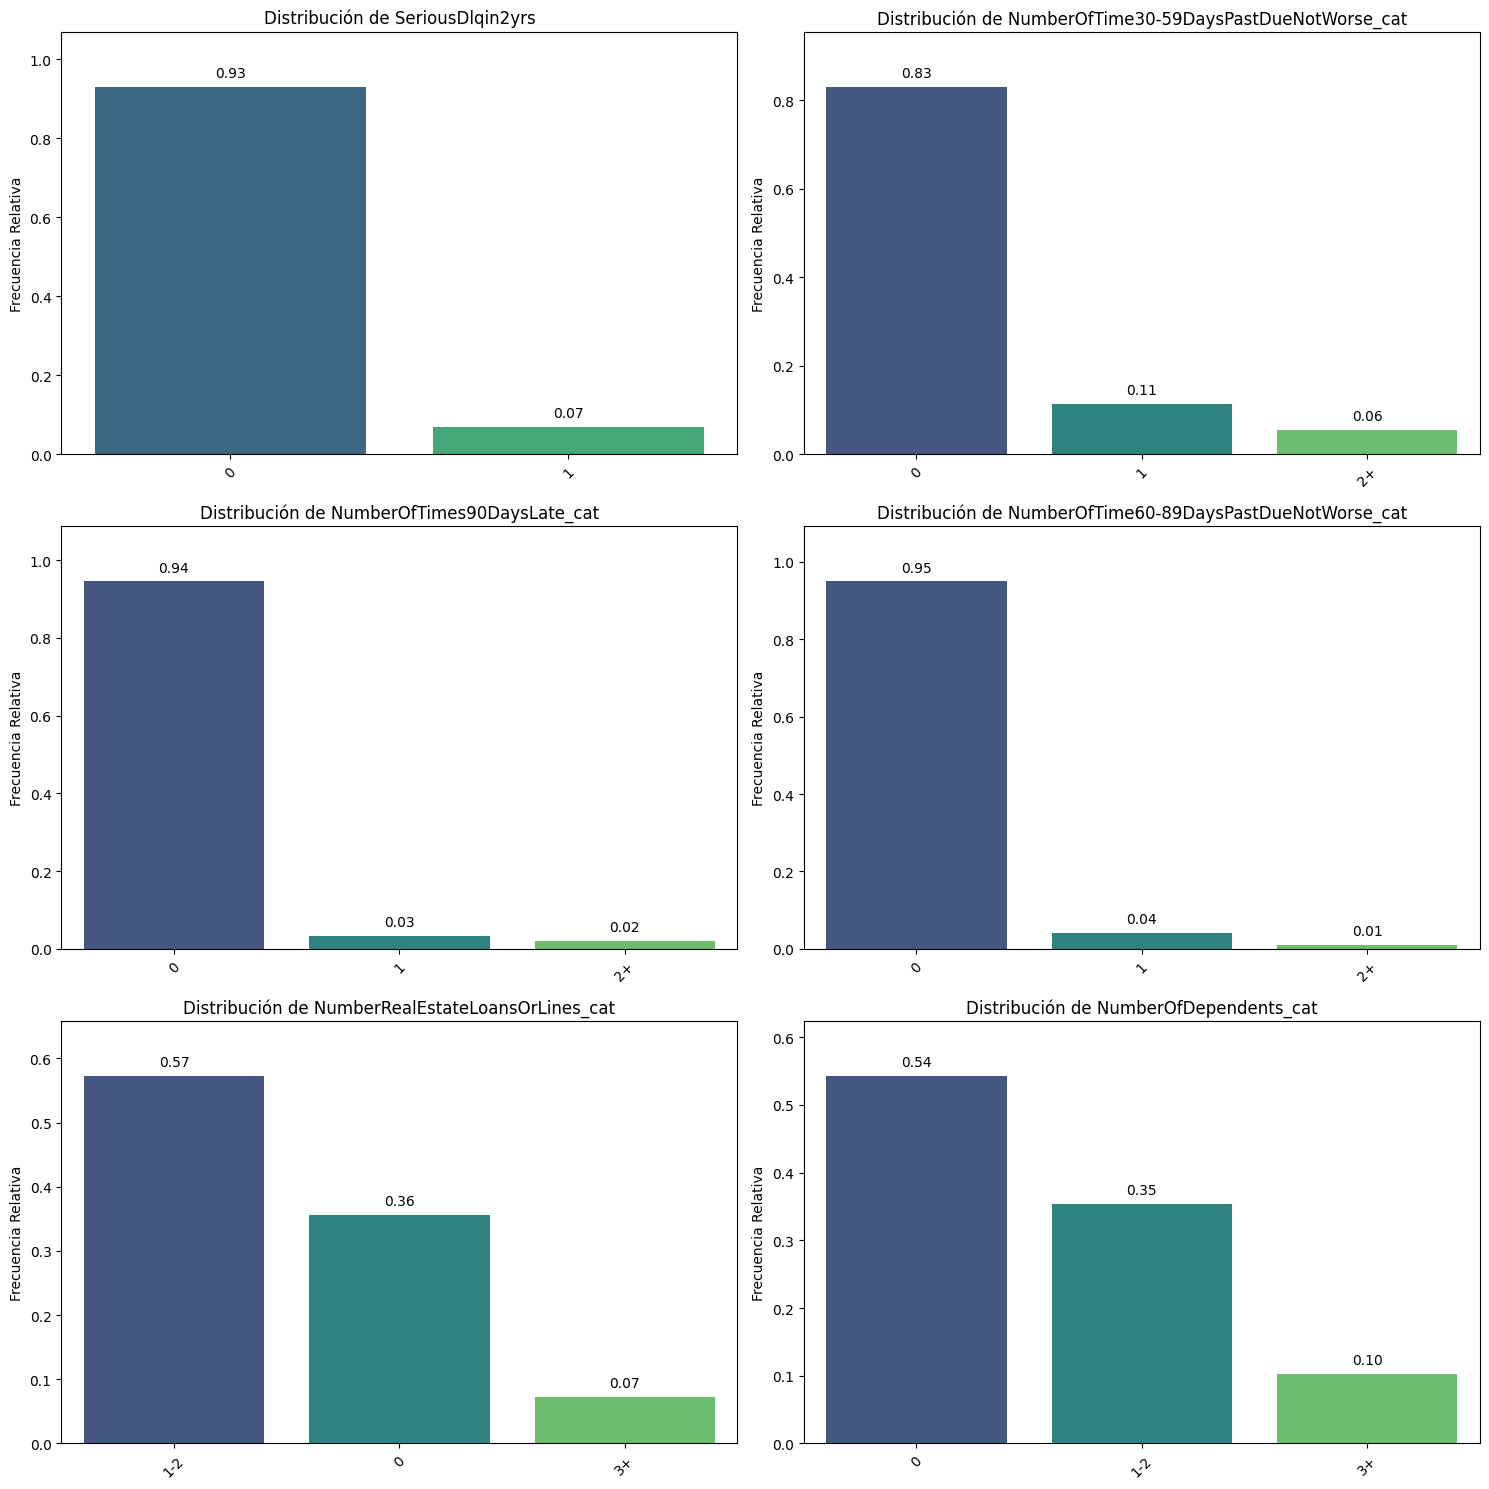

In [ ]:
bt.pinta_distribucion_categoricas(df_train_full, [target] + features_cat, relativa=True, mostrar_valores=True)


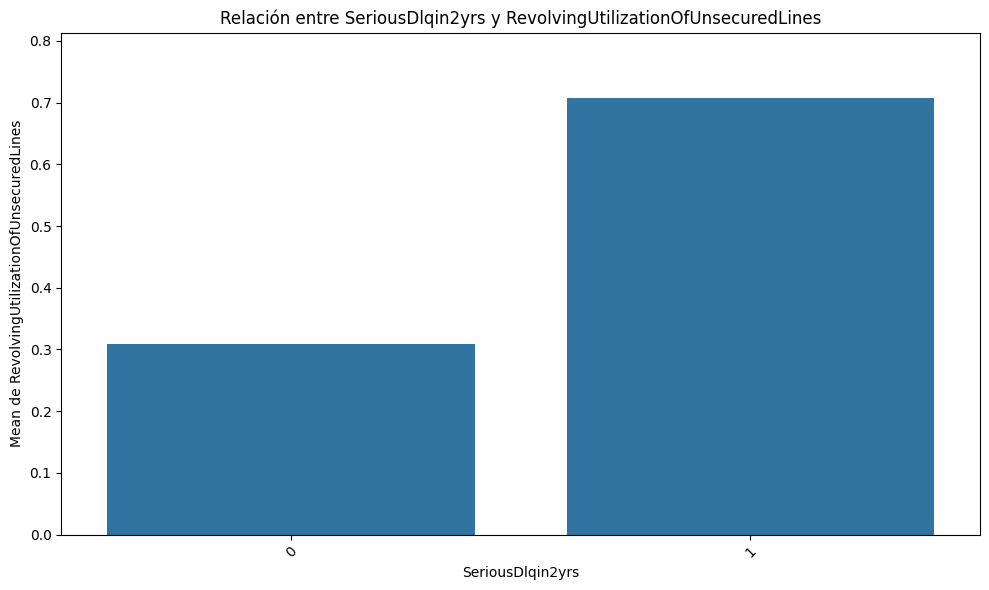

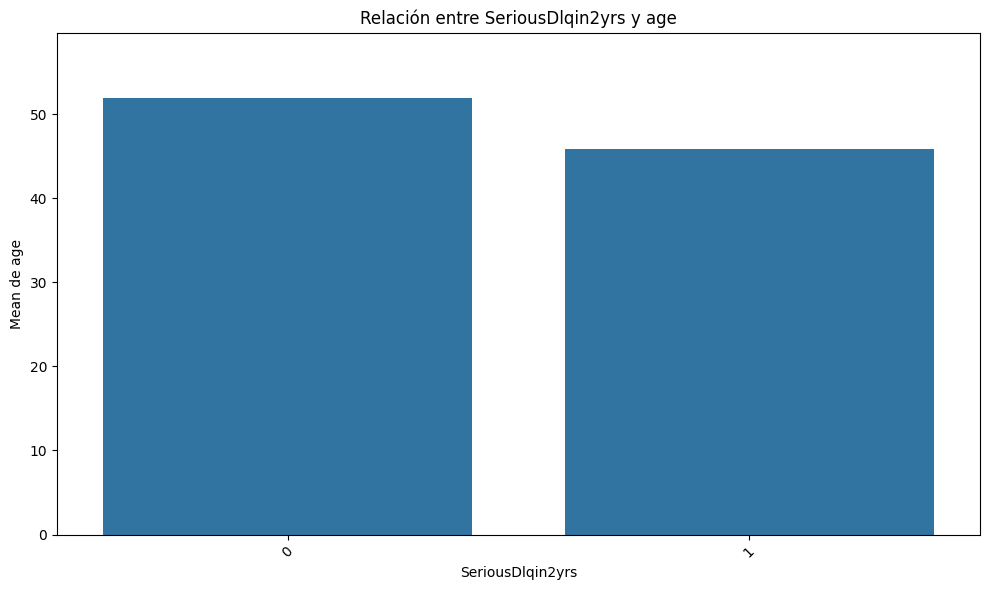

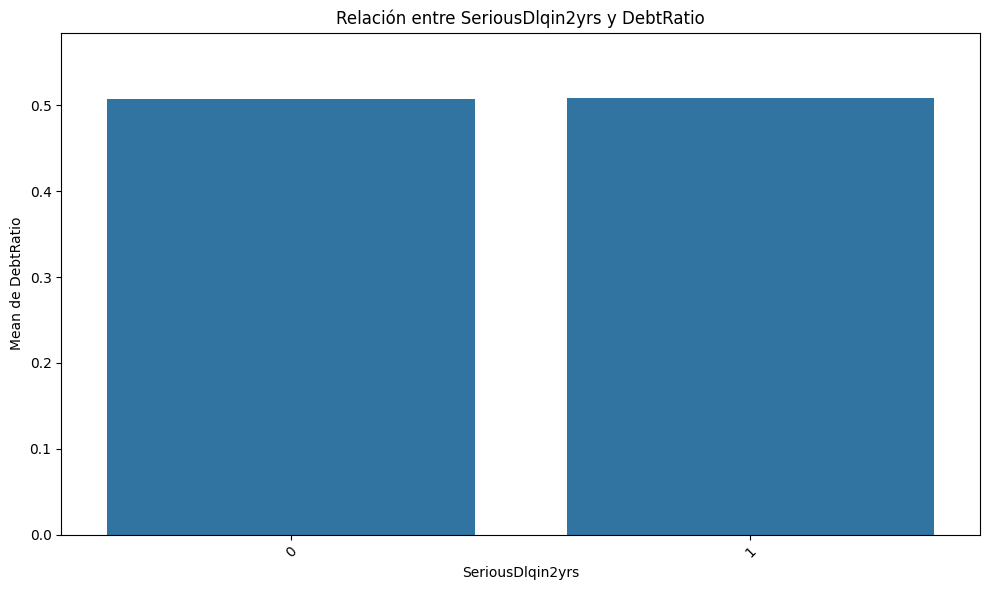

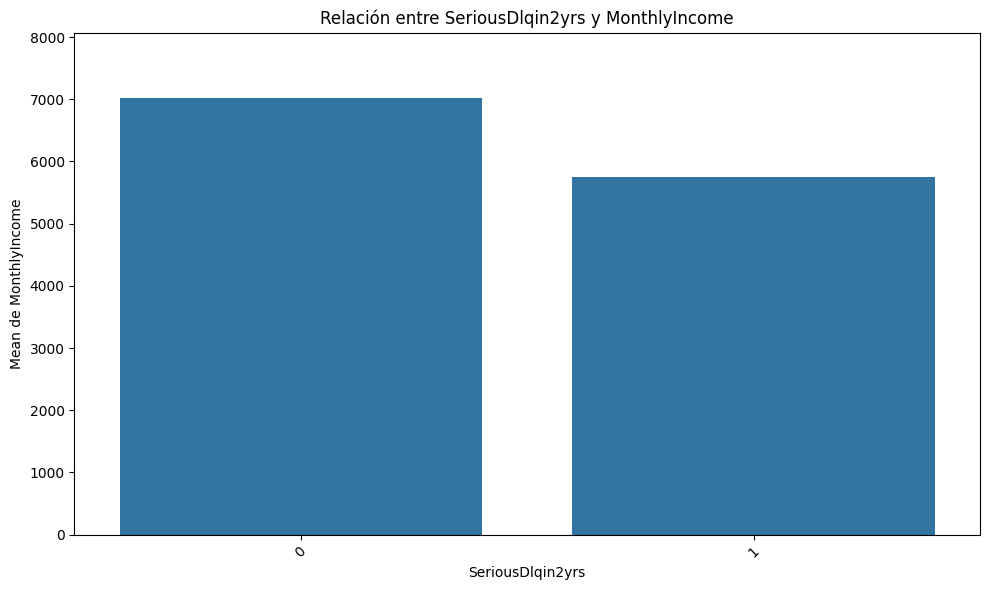

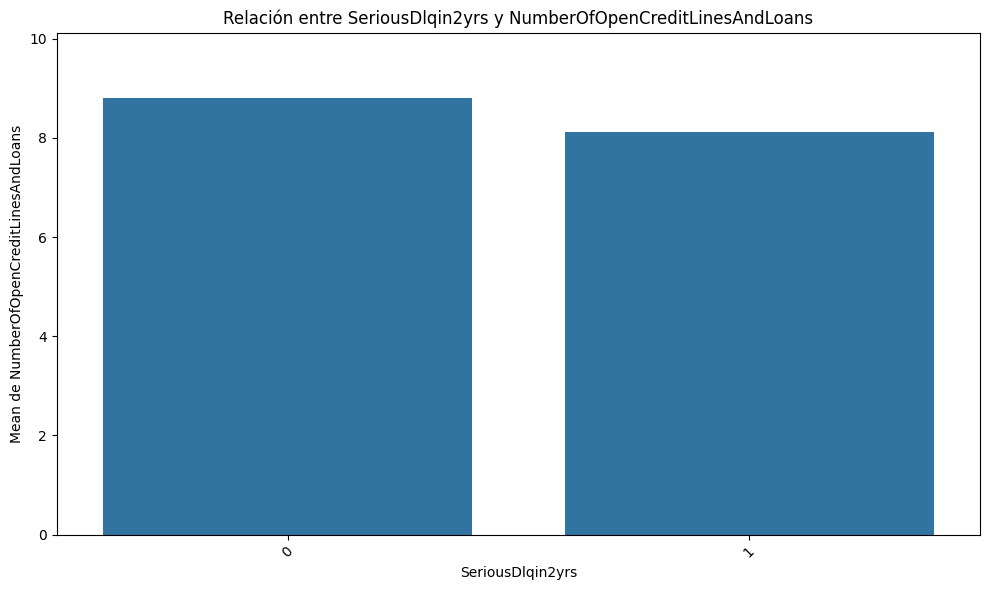

In [ ]:
for feat in features_num:
    bt.plot_categorical_numerical_relationship(df_train_full, target, feat, measure="mean")


Se aprecia que en los clientes que sí tuvieron impago (target=1) suele ser mayor el `RevolvingUtilizationOfUnsecuredLines` y menor la `age`, entre otras cosas. Ahora lo cuantificamos con correlación y covarianza de cada feature (ya numérica/ordinal) contra el target.

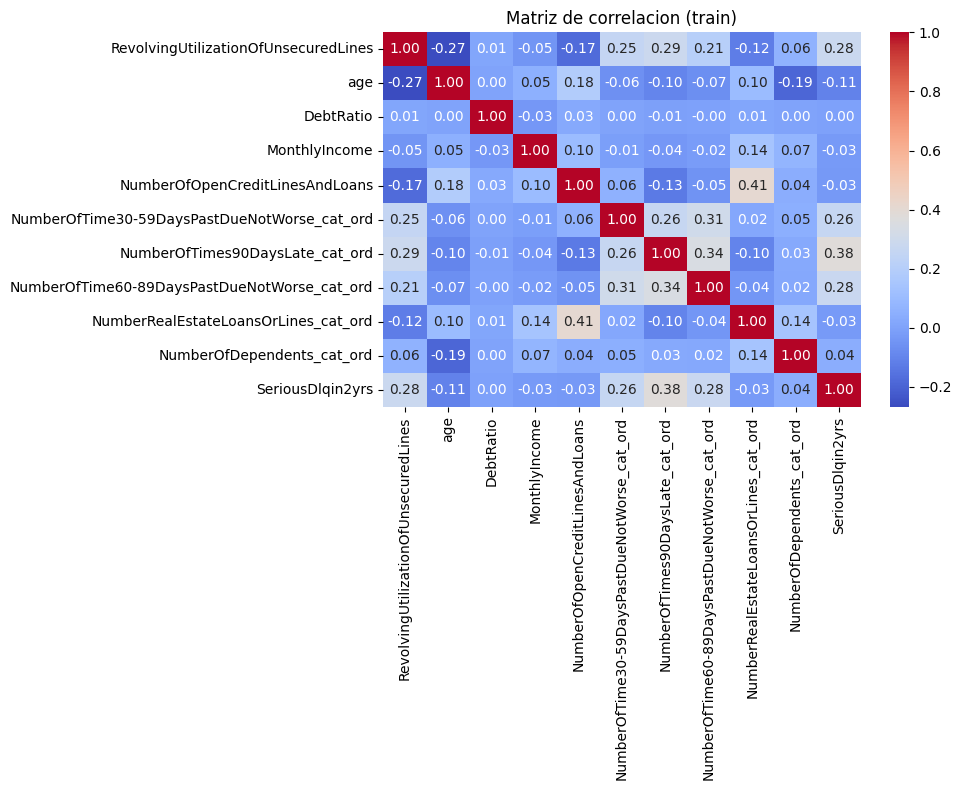

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_train_full[features_all + [target]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlacion (train)")
plt.tight_layout()
plt.show()


In [ ]:
corr_target = df_train_full[features_all].corrwith(df_train_full[target]).abs().sort_values(ascending=False)
print("Correlacion (abs) con el target:")
print(corr_target)

cov_target = df_train_full[features_all].apply(lambda c: np.cov(c, df_train_full[target])[0, 1]).abs().sort_values(ascending=False)
print("\nCovarianza (abs) con el target:")
print(cov_target)

umbral_cov = cov_target.median()
candidatas_cov = cov_target[cov_target >= umbral_cov].index.tolist()
print("\nCandidatas por umbral de covarianza (>= mediana):", candidatas_cov)

features_visual = corr_target.head(6).index.tolist()
print("\nfeatures_visual (top 6 por correlacion):", features_visual)


Correlacion (abs) con el target:
NumberOfTimes90DaysLate_cat_ord                 0.377976
RevolvingUtilizationOfUnsecuredLines            0.277475
NumberOfTime60-89DaysPastDueNotWorse_cat_ord    0.276154
NumberOfTime30-59DaysPastDueNotWorse_cat_ord    0.259018
age                                             0.105251
NumberOfDependents_cat_ord                      0.043564
NumberOfOpenCreditLinesAndLoans                 0.033514
NumberRealEstateLoansOrLines_cat_ord            0.027123
MonthlyIncome                                   0.025449
DebtRatio                                       0.000089
dtype: float64

Covarianza (abs) con el target:
MonthlyIncome                                   83.028944
age                                              0.392272
NumberOfOpenCreditLinesAndLoans                  0.043842
NumberOfTime30-59DaysPastDueNotWorse_cat_ord     0.035425
NumberOfTimes90DaysLate_cat_ord                  0.032604
RevolvingUtilizationOfUnsecuredLines             0.026058
N

*Nota:* la covarianza aquí está muy dominada por la escala de cada variable (`MonthlyIncome` sale con covarianza enorme solo por tener valores en miles), por eso la usamos únicamente como criterio complementario/de apoyo y nos quedamos con la correlación (que sí está normalizada) como lista `features_visual` de "primera división".

### 2.2 SelectKBest (ANOVA) para numéricas + Mutual Information para categóricas

In [ ]:
selector_kbest = SelectKBest(f_classif, k=4)
selector_kbest.fit(X_train[features_num], y_train)
top_num = selector_kbest.get_feature_names_out().tolist()
print("Mejores numericas (ANOVA):", top_num)

mi_scores = mutual_info_classif(X_train[features_cat_ord], y_train, discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=features_cat_ord).sort_values(ascending=False)
print("\nMutual Information categoricas:")
print(mi_series)

top_cat = mi_series.head(2).index.tolist()
features_filter = top_num + top_cat
print("\nfeatures_filter:", features_filter)


Mejores numericas (ANOVA): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

Mutual Information categoricas:
NumberOfTimes90DaysLate_cat_ord                 0.035594
NumberOfTime30-59DaysPastDueNotWorse_cat_ord    0.023412
NumberOfTime60-89DaysPastDueNotWorse_cat_ord    0.020504
NumberRealEstateLoansOrLines_cat_ord            0.001573
NumberOfDependents_cat_ord                      0.000963
dtype: float64

features_filter: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat_ord', 'NumberOfTime30-59DaysPastDueNotWorse_cat_ord']


### 2.3 Selección con un modelo intermedio (SelectFromModel)

In [ ]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

importancias = pd.Series(rf_selector.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importancias)

features_model = importancias.head(6).index.tolist()
print("\nfeatures_model:", features_model)


RevolvingUtilizationOfUnsecuredLines            0.200496
DebtRatio                                       0.166321
MonthlyIncome                                   0.153174
age                                             0.124341
NumberOfOpenCreditLinesAndLoans                 0.106745
NumberOfTimes90DaysLate_cat_ord                 0.102314
NumberOfTime60-89DaysPastDueNotWorse_cat_ord    0.045726
NumberOfTime30-59DaysPastDueNotWorse_cat_ord    0.042974
NumberOfDependents_cat_ord                      0.034523
NumberRealEstateLoansOrLines_cat_ord            0.023385
dtype: float64

features_model: ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat_ord']


### 2.4 RFE (Recursive Feature Elimination)

In [ ]:
rf_rfe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rf_rfe, n_features_to_select=6, step=1)
rfe.fit(X_train, y_train)

features_rfe = list(rfe.get_feature_names_out())
print("features_rfe:", features_rfe)


features_rfe: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat_ord']


### 2.5 SFS (Sequential Feature Selector)

In [ ]:
rf_sfs = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
sfs = SequentialFeatureSelector(rf_sfs, n_features_to_select=6, cv=3, scoring="balanced_accuracy", n_jobs=-1)
sfs.fit(X_train, y_train)

features_sfs = list(sfs.get_feature_names_out())
print("features_sfs:", features_sfs)


features_sfs: ['RevolvingUtilizationOfUnsecuredLines', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat_ord', 'NumberOfTime60-89DaysPastDueNotWorse_cat_ord', 'NumberRealEstateLoansOrLines_cat_ord']


### 2.6 Hard-voting entre todas las técnicas anteriores

In [ ]:
todas_las_listas = [features_visual, features_filter, features_model, features_rfe, features_sfs]

votos = Counter()
for lista in todas_las_listas:
    votos.update(lista)

print("Votos por feature:")
for feat, n in votos.most_common():
    print(f"  {feat}: {n}")

features_voting = [f for f, _ in votos.most_common(6)]
print("\nfeatures_voting:", features_voting)


Votos por feature:
  NumberOfTimes90DaysLate_cat_ord: 5
  RevolvingUtilizationOfUnsecuredLines: 5
  age: 4
  MonthlyIncome: 4
  NumberOfOpenCreditLinesAndLoans: 4
  NumberOfTime60-89DaysPastDueNotWorse_cat_ord: 2
  NumberOfTime30-59DaysPastDueNotWorse_cat_ord: 2
  DebtRatio: 2
  NumberOfDependents_cat_ord: 1
  NumberRealEstateLoansOrLines_cat_ord: 1

features_voting: ['NumberOfTimes90DaysLate_cat_ord', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTime60-89DaysPastDueNotWorse_cat_ord']


In [ ]:
listas_finales = {
    "Visual+Correlacion": features_visual,
    "Filter (ANOVA+MI)": features_filter,
    "SelectFromModel": features_model,
    "RFE": features_rfe,
    "SFS": features_sfs,
    "Hard-Voting": features_voting,
}

resumen_listas = pd.DataFrame([
    {"metodo": k, "n_features": len(v), "features": ", ".join(v)}
    for k, v in listas_finales.items()
])
resumen_listas


,metodo,n_features,features
0,Visual+Correlacion,6,"NumberOfTimes90DaysLate_cat_ord, RevolvingUtil..."
1,Filter (ANOVA+MI),6,"RevolvingUtilizationOfUnsecuredLines, age, Mon..."
2,SelectFromModel,6,"RevolvingUtilizationOfUnsecuredLines, DebtRati..."
3,RFE,6,"RevolvingUtilizationOfUnsecuredLines, age, Deb..."
4,SFS,6,"RevolvingUtilizationOfUnsecuredLines, MonthlyI..."
5,Hard-Voting,6,"NumberOfTimes90DaysLate_cat_ord, RevolvingUtil..."


## 3. Comparativa de 3 modelos × 6 listas de features

Elegimos tres modelos con lógicas bien distintas: `LogisticRegression` (lineal), `RandomForestClassifier` (bagging) y `GradientBoostingClassifier` (boosting). Los evaluamos con validación cruzada (5 folds) sobre train, usando cada una de las 6 listas de features. Como métrica usamos `balanced_accuracy`, que es la más adecuada dado el desbalance del target (le da el mismo peso a acertar en la clase 0 que en la clase 1, en vez de premiar simplemente acertar en la clase mayoritaria).

A `LogisticRegression` le pasamos `class_weight="balanced"` para que compense el desbalance de clases durante el entrenamiento.

In [ ]:
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

resultados_comparativa = []
for nombre_lista, cols in listas_finales.items():
    for nombre_modelo, modelo in modelos.items():
        score = cross_val_score(modelo, X_train[cols], y_train, cv=5,
                                 scoring="balanced_accuracy", n_jobs=-1).mean()
        resultados_comparativa.append({
            "lista_features": nombre_lista, "modelo": nombre_modelo,
            "n_features": len(cols), "balanced_accuracy_cv": score,
        })

resultados_comparativa_df = pd.DataFrame(resultados_comparativa).sort_values(
    "balanced_accuracy_cv", ascending=False).reset_index(drop=True)
resultados_comparativa_df


,lista_features,modelo,n_features,balanced_accuracy_cv
0,Filter (ANOVA+MI),LogisticRegression,6,0.768127
1,Visual+Correlacion,LogisticRegression,6,0.762189
2,Hard-Voting,LogisticRegression,6,0.760781
3,SFS,LogisticRegression,6,0.760220
4,RFE,LogisticRegression,6,0.743396
5,SelectFromModel,LogisticRegression,6,0.743396
6,SFS,GradientBoosting,6,0.611637
7,Hard-Voting,GradientBoosting,6,0.607702
8,SelectFromModel,GradientBoosting,6,0.605149
9,RFE,GradientBoosting,6,0.605092


In [ ]:
mejor_fila = resultados_comparativa_df.iloc[0]
mejor_lista_nombre = mejor_fila["lista_features"]
mejor_modelo_nombre = mejor_fila["modelo"]
mejor_features = listas_finales[mejor_lista_nombre]

print(f"Mejor combinacion -> modelo: {mejor_modelo_nombre} | lista: {mejor_lista_nombre} "
      f"| balanced_accuracy CV: {mejor_fila['balanced_accuracy_cv']:.4f}")
print("Features:", mejor_features)


Mejor combinacion -> modelo: LogisticRegression | lista: Filter (ANOVA+MI) | balanced_accuracy CV: 0.7681
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat_ord', 'NumberOfTime30-59DaysPastDueNotWorse_cat_ord']


**¿Por qué gana `LogisticRegression` con tanta diferencia?** Las 6 primeras filas de la tabla son todas de `LogisticRegression` (0.74-0.77), y luego hay un salto grande hasta `GradientBoosting`/`RandomForest` (0.58-0.61). Esto tiene sentido dado el desbalance tan fuerte del target (~93%/7%): `LogisticRegression` con `class_weight="balanced"` reajusta explícitamente el peso de cada clase en la función de pérdida, mientras que `RandomForest` y `GradientBoosting` (sin ese ajuste) tienden a "conformarse" con acertar la clase mayoritaria y su recall en la clase minoritaria se resiente mucho, penalizando fuertemente el `balanced_accuracy`.

La lista ganadora es la de filtrado por ANOVA + Mutual Information, aunque está muy cerca de las demás listas (todas las basadas en `LogisticRegression` rondan 0.74-0.77), lo cual indica que el propio modelo pesa más que la lista de features concreta elegida.

## 4. Optimización de hiperparámetros y evaluación en test

In [ ]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    param_grid, cv=5, scoring="balanced_accuracy", n_jobs=-1,
)
grid.fit(X_train[mejor_features], y_train)

print("Mejores hiperparametros:", grid.best_params_)
print("Mejor balanced_accuracy en CV:", grid.best_score_)


Mejores hiperparametros: {'C': 1}
Mejor balanced_accuracy en CV: 0.7681273702989249


In [ ]:
modelo_final = grid.best_estimator_
y_pred_test = modelo_final.predict(X_test[mejor_features])

print("balanced_accuracy en TEST:", balanced_accuracy_score(y_test, y_pred_test))
print()
print(classification_report(y_test, y_pred_test))


balanced_accuracy en TEST: 0.759480140763235

              precision    recall  f1-score   support

           0       0.97      0.80      0.88      2198
           1       0.21      0.72      0.33       166

    accuracy                           0.80      2364
   macro avg       0.59      0.76      0.61      2364
weighted avg       0.92      0.80      0.84      2364



El resultado en test (balanced_accuracy ≈ 0.76) es prácticamente idéntico al de validación cruzada, así que el modelo generaliza bien y no hay sobreajuste a la selección de features. Como es esperable con `class_weight="balanced"`, el modelo sacrifica precisión en la clase 1 (impago) a cambio de un recall mucho más alto (~0.72, frente a lo que sacaría un modelo sin balancear): detecta la mayoría de los impagos reales, aunque a costa de bastantes falsos positivos, algo razonable en un problema de scoring de crédito donde "dejar pasar" un impago suele ser más costoso que investigar de más a un cliente solvente.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

Escalamos las features (imprescindible para PCA, que es sensible a la escala) y miramos cuánta varianza acumulada explica cada número de componentes.

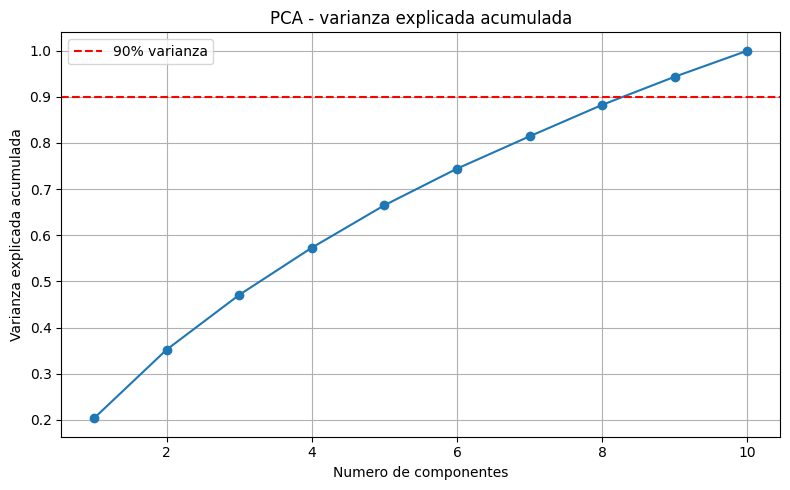

Varianza acumulada por componente: [0.203 0.352 0.471 0.573 0.665 0.744 0.814 0.883 0.944 1.   ]


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[features_all])
X_test_scaled = scaler.transform(X_test[features_all])

pca_full = PCA(random_state=42).fit(X_train_scaled)
var_acum = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% varianza")
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - varianza explicada acumulada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Varianza acumulada por componente:", np.round(var_acum, 3))


In [ ]:
n_comp = int(np.argmax(var_acum >= 0.90) + 1)
print(f"Componentes necesarios para explicar >=90% de la varianza: {n_comp}")

pca = PCA(n_components=n_comp, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Shape train tras PCA:", X_train_pca.shape)


Componentes necesarios para explicar >=90% de la varianza: 9
Shape train tras PCA: (9452, 9)


Entrenamos el mismo tipo de modelo ganador de la parte general (`LogisticRegression` con `class_weight="balanced"` y los mismos hiperparámetros encontrados con `GridSearchCV`), esta vez sobre las componentes principales.

In [ ]:
modelo_pca = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42, **grid.best_params_)
modelo_pca.fit(X_train_pca, y_train)

y_pred_test_pca = modelo_pca.predict(X_test_pca)
print("balanced_accuracy en TEST (PCA):", balanced_accuracy_score(y_test, y_pred_test_pca))
print()
print(classification_report(y_test, y_pred_test_pca))


balanced_accuracy en TEST (PCA): 0.7790899722639419

              precision    recall  f1-score   support

           0       0.98      0.81      0.89      2198
           1       0.23      0.75      0.35       166

    accuracy                           0.81      2364
   macro avg       0.60      0.78      0.62      2364
weighted avg       0.92      0.81      0.85      2364



**Comentario del resultado:** con PCA hacen falta 9 de las 10 componentes originales para llegar al 90% de varianza explicada, es decir, en este dataset las features ya venían bastante poco correlacionadas entre sí (cada una aporta información relativamente propia), así que PCA apenas comprime nada. Aun así, el modelo entrenado con esas 9 componentes obtiene un balanced_accuracy en test (≈0.78) ligeramente superior al del modelo con las 6 features seleccionadas explícitamente (≈0.76).

Esto no es contradictorio: PCA con 9 componentes conserva prácticamente toda la información de las 10 features originales (solo descarta la componente que menos varianza aporta), mientras que la selección de features de la Sección 2 sí descarta información activamente (se queda solo con 6 de 10 variables) buscando simplicidad e interpretabilidad. La comparación justa no es tanto "¿cuál acierta más?" sino el compromiso entre ambas cosas: la selección explícita de features pierde un poco de rendimiento pero mantiene variables con significado de negocio directo (utilización de crédito, edad, ingresos, impagos previos...), mientras que las componentes de PCA son combinaciones lineales de las 10 variables sin interpretación directa. Para un caso de uso real de scoring de crédito, donde poder explicar el modelo suele ser importante, la ligera pérdida de balanced_accuracy de la selección de features frente a PCA parece un precio razonable a cambio de interpretabilidad.